# Cooperation dynamics of LLM agents — source of truth

**Branch `donors-game-dynamics`, package `llm_dynamics/`.** This notebook is
regenerated by `llm_dynamics/build_notebook.py`; every table and figure below is
read from `llm_dynamics/results/` at execution time, so it always reflects the
latest runs. Narrative sections record the *decisions* (design, mappings,
deviations, caveats); code cells record the *evidence*.

## 0. What we are doing, in one paragraph

MARL-mixed studies the **dynamics of cooperation** — not just whether agents end up
cooperating, but the vector field of learning that carries them there — using
CRLD flow fields (pyCRLD) and, for learners without a closed-form flow (deep RL),
measured trajectories overlaid on the analytic flow of the reduced matrix game.
donorSim (branch `neurips-methodology`) trains LLMs with RL (verl GRPO; reward =
normalized donors-game payoff + HKB coordination term + CFE group term) on a
dyadic donors game against scripted strategies, and claims the training
**changes the LLM's dynamics**. Here we make that claim measurable: the same
phase portraits, with an LLM in the learner's seat — first the **base model**
(this notebook), then the RL-trained checkpoint on the same axes.


## 1. Background we build on

### 1.1 MARL-mixed methodology (this repo)
* State of the system = joint policy $X_i(a\mid s)$. A flow plot is a 2-D slice
  (agent-0 $P(C)$ vs agent-1 $P(C)$ in a chosen memory state); arrows are the
  deterministic CRLD learning step $\Delta X = \mathrm{step}(X)-X$
  (`pyCRLD.Utils.FlowPlot.plot_strategy_flow`, `use_RPEarrows=False`), with
  off-slice coordinates marginalized by Latin-hypercube sampling.
* Memory-$m$ games via `HistoryEmbedded(env, h=(m,)*(N+1))`, state count $(2^N)^m$.
* Observability regimes = row-stochastic observation-aliasing matrices
  (`scratch_repro/mem_obs_grids.py`: full / self / others / coop / def / blind).
* Learners with no analytic flow (JaxMARL deep RL, `jaxmarl_env/algo_phase.py`):
  grey CRLD arrows as theory, coloured measured paths as reality, **the deviation
  is the finding**.
* Paper findings we lean on: self-observability is load-bearing; memory enlarges
  the cooperative basin (memory-1 flow drains to defection, memory-2 has a (1,1)
  attractor); actor-critic is bistable, SARSA converges to an interior point.

### 1.2 donorSim `neurips-methodology`
* **Basic dyadic scenario** = the `direct_indirect` training rollout
  (`donor_sim/verl_integration/donor_game_interaction.py` +
  `donor_sim/game_helpers.py`): one LLM vs one scripted partner drawn from
  `OPPONENT_POOL` = {AllC .15, AllD .30, TFT .20, TF2T .20, Random .10, Grim .05};
  $b\sim U[3,6]$, $c/b\sim U[0.1,1.5]$, $w,q\in\{0,.25,.5,.75,1\}$, 3–8 rounds.
* Semantics: simultaneous moves ("If you COOPERATE: you receive 0, partner
  receives $b$; if you DEFECT: you receive $c$"); partner reacts to the model's
  *prior* rounds; **$w$** = probability the same partner returns next round
  (else a stranger arrives, per-partner history wiped); **$q$** = probability a
  reputation report about the partner is available.
* Training: verl GRPO (LoRA r=16, KL 0.001, 8 generations, per-turn credit),
  reward $r = \frac{\pi + c}{b+c} + \lambda_{tom}[4q\cos\phi + \tfrac{c}{b}\cos 2\phi] - \lambda_g\,\mathrm{CFE}$
  with HKB phase $\phi$ from a window-4 coordination signal; phase transition at
  $q = c/b$ (Nowak's indirect-reciprocity threshold). Released run on Qwen3-8B;
  a Qwen3-32B methodology checkpoint (`step_175`) exists.
* Eval stack already reads a continuous $p_{coop}$ from decision-token logprobs
  (`metastability_eval/harness/vllm_client.py`); branch `metastability-eval`
  holds the drift/dwell/Markov analyses.


## 2. The theory mapping: donors game → CRLD

| donorSim | CRLD (`llm_dynamics/donors_crld.py`) |
|---|---|
| payoffs $(b,c)$, both players donors | donation-game PD $(R,T,S,P)=(b-c,\;b,\;-c,\;0)$; on the training's normalized scale $\big(\tfrac{b}{b+c},1,0,\tfrac{c}{b+c}\big)$ (default) |
| $w$ — re-encounter probability | discount factor $\gamma=w$ (clamped to 0.99). Continuation probability *is* the discount factor of the repeated game; Nowak's $w>c/b$ is the discounted-game threshold |
| $q$ — reputation availability | observability blend $O = q\,O_{\text{full}} + (1-q)\,O_{\text{self}}$ — the partner's action is visible w.p. $q$, else only one's own |
| per-partner memory | `HistoryEmbedded(env, h=(m,m,m))` |
| set-strategy opponent | pinned policy $X_{opp}[s,a]$ (AllC/AllD/TFT/TF2T/Grim-$m$/WSLS, $\epsilon$-mixed); the learner's seat gets a **fixed-opponent flow field** |

Two backgrounds are therefore available for every $(b,c,w,q,m)$:
1. **two-agent CRLD flow** (both seats learning) in the *cooperation plane*
   $(P_{model}(C),\,P_{partner}(C))$ — the repo convention;
2. **fixed-opponent flow** in the *reciprocity plane*
   $\big(P(C\mid\text{sustained mutual }C),\;P(C\mid\text{own }C,\text{ partner }D)\big)$ —
   the theoretically matched background for "set strategy vs LLM".


In [1]:
# Live: the CRLD flow of the donors game at the sweep's parameters, both backgrounds.
import os, sys, json, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd())=='llm_dynamics' else os.getcwd()
sys.path.insert(0, ROOT); os.chdir(ROOT)
from llm_dynamics import donors_crld as dc, plots
from pyCRLD.Utils import FlowPlot as fp
b, c, w, q, m = 4.0, 2.0, 0.75, 0.75, 1
memo = dc.donors_memo_env(b, c, memory=m, q=q); mae = dc.build_mae(memo, w=w, q=q)
fig, axs = plt.subplots(1, 2, figsize=(10, 4.6))
plots.crld_flow_background(axs[0], mae, dc.allc_state(memo))
axs[0].set_title(f'two-agent CRLD flow (b={b:g}, c/b={c/b:g}, γ=w={w}, q={q}, memory {m})', fontsize=9)
axs[0].set_xlabel('agent 0 P(C)'); axs[0].set_ylabel('agent 1 P(C)')
X_opp = dc.strategy_policy('tit_for_tat', memo)
XX, YY, dX, dY = dc.fixed_opponent_flow(mae, memo, X_opp, dc.uniform_state(memo,'c','c',m), dc.uniform_state(memo,'c','d',m), NrRandom=6)
mdx, mdy = dX.mean(-1), dY.mean(-1); L = np.sqrt(mdx**2+mdy**2)+1e-12
axs[1].quiver(XX, YY, mdx*np.sqrt(L)/L, mdy*np.sqrt(L)/L, color='0.6', angles='xy')
axs[1].set_title('fixed-opponent flow vs TFT (reciprocity plane)', fontsize=9)
axs[1].set_xlabel('P(C | sustained mutual C)'); axs[1].set_ylabel('P(C | own C, partner D)')
for a in axs: a.set_xlim(-.03,1.03); a.set_ylim(-.03,1.03)
plt.tight_layout(); plt.show()

## 3. How the LLM is measured

* **Order parameter.** `p_cooperate` = renormalized COOPERATE-mass vs DEFECT-mass
  in the top-20 logprobs at the token after the *last* `DECISION:` marker
  (`llm_client.decision_probability`). It reads the distribution the sampler
  drew from; decoding is unchanged. Because the model writes a rationale before
  `DECISION:` (sampled at $T=0.6$), a single call's $p$ is near-binary — the
  stochasticity lives in the rationale — so means over seeds/rounds are needed.
* **Probes** (`policy_probe.py`): render the exact prompt for every memory-$m$
  history state ($4^m$ states) and read $p$ greedily → the LLM as a point
  $X[s]$ in CRLD policy space. Donors framing = conversational replay with forced
  `DECISION:` assistant turns; matrix framing = the stateless memory-$m$ prompt.
* **Play** (`donors_game.py`, `matrix_games.py`): full games vs a fixed
  strategy, per-round JSONL (`model_action`, `opp_action`, `p_cooperate`, HKB
  $\phi$, payoffs on both scales, swap events, visible state).
* **Portraits** (`plots.py`): cooperation-plane paths (sliding window 8) over the
  two-agent flow; reciprocity-plane stars (probes) + paths (windowed conditional
  frequencies) over the fixed-opponent flow; $q\times w$ heatmaps with the
  $q=c/b$ line.
* **Optimality gaps** (`analysis.py`), two optima by dynamic programming over
  the fixed strategy's state machine, per partner segment (swaps wipe the
  opponent's memory), same horizon:
  - **best-response captured** = model payoff ÷ the max payoff an oracle could
    extract from that strategy ("against AllD the model should AllD" ⇔ 1.0);
  - **welfare captured** = joint payoff ÷ the max joint (model + partner) payoff
    reachable against that strategy — the utilitarian point of the Pareto
    frontier the model controls (mutual cooperation vs TFT/AllC). The two
    disagree exactly where reciprocity and altruism disagree: vs AllD the
    welfare optimum is to be exploited (joint 6/round vs 4), so a perfect
    reciprocator scores BR 1.00 / welfare 0.67.

### 3.0 Opponent strategies (all nine)

| strategy | rule | reference behaviour |
|---|---|---|
| AllC | C every round | all C |
| AllD | D every round | all D (all C in Chicken / Harmony, where $S>P$) |
| TFT | opens C, mirrors your last move | all C |
| TF2T | opens C, defects after two consecutive D | all C |
| Grim | C until your first D, then D forever | all C |
| Random | C/D with prob ½ | D |
| suspicious TFT | opens **D**, then mirrors | all C |
| WSLS (Pavlov) | repeat if you cooperated, switch if you defected | all C |
| generous TFT | TFT, forgives a D with prob 0.3 | all C |

The first six are donorSim's training pool (`OPPONENT_POOL`); the last three
are added here. Each is also a pinned CRLD policy (fixed-opponent flows) and a
finite-state machine for the dynamic programs.

### 3.1 Fidelity to the training environment (deliberate choices)
* Donors prompts are byte-faithful to the `direct_indirect` rollout (rules,
  $w$/$q$ phrasing, $q$-gated reputation report, `/no_think`, round-result
  turns, swap text). Strategies, payoffs, HKB, parsing are vendored verbatim
  (`strategies.py`, from `game_helpers.py` @ merge-base `e665f87`).
* **Deviation:** `--swap-mode same` — a successor partner keeps the *same*
  strategy so the dyad stays strategy-controlled (`pool` reproduces training).
* **Addition:** `suspicious_tit_for_tat` (opens D, then mirrors) — not in the
  training pool; used so that half of the TFT games open with D.
* **Addition:** an LLM memory window for the donors framing (`--memories`):
  the rules prompt + only the last $m$ (assistant, round-result) turn pairs.
  `full` is the training setting.
* Matrix games are **stateless** per round with an explicit last-$m$ history
  block, so the LLM is genuinely a memory-$m$ policy on exactly the CRLD state
  space. Payoffs: PD (3,5,0,1), Chicken (3,5,1,0), Stag Hunt (5,3,0,1),
  Harmony (5,3,2,0) as $(R,T,S,P)$.
* Qwen3 thinking mode is **off** (`enable_thinking=False` + `/no_think`), the
  stage-1 training setting. Temperature 0.6 for play, 0 for probes.

### 3.2 Compute rule
**Everything GPU runs through SLURM** (`llm_dynamics/slurm/*.sbatch`), never on
`rnn`. Server: `serve_qwen32b.sbatch` (vllm-env, one A100-80GB, writes
`logs/vllm_endpoint.txt` + `.ready`). Clients are CPU jobs that wait on the
sentinel. `llm_dynamics/README.md` has the commands.


## 4. Experiment registry — `qwen8b_base` (v3)

Design (identical for base and trained checkpoints, so tables are directly comparable):

* donors game (training-faithful prompts): 9 strategies × (w,q) ∈ {0, .5, 1}² × LLM memory
  {full, 1, 2, note2} × 4 seeds × 20 rounds at c/b = 0.5; c/b ∈ {0.25, 0.75, 1.0, 1.25} at
  w ∈ {0.5, 1}, q ∈ {0, 1}; horizons N ∈ {5, 10}; thinking-on subset at w = 1
* perturbation/repair: forced defection at round 8 vs TFT, Grim, WSLS, TF2T, generous TFT
* self-play (model vs itself) at (w,q) ∈ {0, 1}²
* group-selection stage (the trained environment, thinking on): 50 scenarios × 2 seeds,
  PREDICT + DECISION, CFE / Brier / ρ / bonus / trajectory scalar
* matrix games: PD, Chicken, Stag Hunt, Harmony × memory {1, 2, 3} × 9 strategies × 4 seeds
* probes to memory 3, both framings

Outputs: `results/qwen8b_base_*_v3*/`, `results/probes/qwen8b_base_*`, `results/qwen8b_base_v3_tables.md`.


## 5. Results

### 5.1 Probed conditional policy (donors framing, memory 1 and 2)

In [2]:
from IPython.display import Image, display as _d
def show_probes(pattern):
    rows = []
    for f in sorted(glob.glob(pattern)):
        p = json.load(open(f)); name = os.path.basename(f).replace('.json','')
        row = {'probe': name}
        row.update({k: v['p_cooperate'] for k, v in sorted(p['states'].items())})
        rows.append(row)
    return pd.DataFrame(rows).set_index('probe').round(2) if rows else 'pending'
display(show_probes('llm_dynamics/results/probes/qwen8b_base_donors_m1_*.json'))
display(show_probes('llm_dynamics/results/probes/qwen8b_base_donors_m2_*.json').T)
for g in ['ipd','chicken','staghunt','harmony']:
    print(g); display(show_probes(f'llm_dynamics/results/probes/qwen8b_base_{g}_m1.json'))

,cc,cd,dc,dd
probe,,,,
qwen8b_base_donors_m1_w0.25_q0.25,1.0,1.0,1.0,0.0
qwen8b_base_donors_m1_w0.75_q0.75,1.0,1.0,1.0,0.0


probe,qwen8b_base_donors_m2_w0.25_q0.25,qwen8b_base_donors_m2_w0.75_q0.75
cc|cc,1.00,1.00
cc|cd,1.00,1.00
cc|dc,0.01,0.00
cc|dd,0.15,0.08
cd|cc,1.00,1.00
cd|cd,0.82,0.68
cd|dc,0.00,0.00
cd|dd,0.00,0.00
dc|cc,1.00,1.00
dc|cd,1.00,1.00


ipd


,cc,cd,dc,dd
probe,,,,
qwen8b_base_ipd_m1,1.0,0.0,0.0,0.0


chicken


,cc,cd,dc,dd
probe,,,,
qwen8b_base_chicken_m1,1.0,0.0,0.0,0.0


staghunt


,cc,cd,dc,dd
probe,,,,
qwen8b_base_staghunt_m1,1.0,0.0,0.0,0.0


harmony


,cc,cd,dc,dd
probe,,,,
qwen8b_base_harmony_m1,1.0,0.0,0.0,0.0


### 5.2 All tables

Per-strategy tables (cell = agreement with the reference policy · model/reference payoff ·
best-response captured · welfare captured), unknown-partner tables (blind-policy optimum
under equal and training-pool priors), c/b sweep, thinking-on subset, horizons, and the
training-signal view (mean ρ · mean r₁ · std of the trajectory scalar across seeds ·
inference latency) with the repair table. Reference = all-C vs AllC and conditional
cooperators, all-D vs AllD (all-C in Chicken/Harmony).

In [3]:
from IPython.display import Markdown
f = 'llm_dynamics/results/qwen8b_base_v3_tables.md'
display(Markdown(open(f).read()) if os.path.exists(f) else Markdown('**tables pending**'))


### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 0.99 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.47 · 19/40 · 0.47 · 0.84 | 0.95 · 38/40 · 0.95 · 0.68 | 0.99 · 40/40 · 0.99 · 0.67 | 0.60 · 24/40 · 0.60 · 0.80 | 0.86 · 34/40 · 0.86 · 0.71 | 0.97 · 39/40 · 0.97 · 0.68 | 0.94 · 38/40 · 0.94 · 0.69 | 0.93 · 37/40 · 0.93 · 0.69 | 0.99 · 40/40 · 0.99 · 0.67 |
| generous_tit_for_tat | 0.50 · 100/80 · 0.83 · 0.88 | 0.82 · 87/80 · 0.72 · 0.96 | 0.84 · 86/80 · 0.72 · 0.96 | 1.00 · 80/80 · 0.77 · 1.00 | 0.79 · 82/80 · 0.78 · 0.93 | 0.84 · 82/80 · 0.79 · 0.95 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 1.00 · 80/80 · 0.67 · 1.00 | 0.97 · 81/80 · 0.68 · 0.99 | 0.96 · 82/80 · 0.68 · 0.99 | 1.00 · 80/80 · 0.77 · 1.00 | 0.97 · 81/80 · 0.76 · 0.99 | 0.90 · 79/80 · 0.76 · 0.96 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 0.64 · 62/80 · 0.77 · 0.80 | 0.40 · 47/80 · 0.59 · 0.85 | 0.49 · 52/80 · 0.66 · 0.84 | 0.61 · 60/80 · 0.76 · 0.81 | 0.53 · 58/80 · 0.72 · 0.84 | 0.42 · 50/80 · 0.62 · 0.85 | 0.64 · 62/80 · 0.77 · 0.80 | 0.68 · 58/80 · 0.72 · 0.78 | 0.60 · 52/80 · 0.65 · 0.79 |
| suspicious_tit_for_tat | 0.76 · 10/0 · 0.24 · 0.92 | 0.41 · 24/0 · 0.59 · 0.80 | 0.54 · 18/0 · 0.46 · 0.85 | 0.30 · 40/33 · 0.71 · 0.72 | 0.30 · 35/28 · 0.65 · 0.71 | 0.35 · 36/33 · 0.64 · 0.73 | 0.29 · 50/76 · 0.65 · 0.65 | 0.29 · 50/76 · 0.65 · 0.65 | 0.56 · 60/76 · 0.78 · 0.78 |
| tit_for_tat | 1.00 · 80/80 · 0.67 · 1.00 | 0.97 · 81/80 · 0.67 · 0.99 | 0.95 · 82/80 · 0.68 · 0.99 | 0.99 · 80/80 · 0.78 · 1.00 | 0.99 · 80/80 · 0.76 · 1.00 | 1.00 · 80/80 · 0.77 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 0.97 · 81/80 · 0.67 · 0.99 | 1.00 · 80/80 · 0.69 · 1.00 | 0.99 · 80/80 · 0.69 · 1.00 | 1.00 · 80/80 · 0.69 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 1.00 · 80/80 · 0.67 · 1.00 | 0.66 · 94/80 · 0.78 · 0.92 | 0.62 · 95/80 · 0.79 · 0.91 | 0.56 · 86/80 · 0.83 · 0.85 | 0.94 · 80/80 · 0.76 · 0.98 | 0.99 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |

### Donors game — LLM memory m1  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 0.97 · 81/80 · 0.68 · 0.99 | 0.75 · 90/80 · 0.75 · 0.94 | 0.97 · 81/80 · 0.67 · 0.99 | 0.61 · 96/80 · 0.80 · 0.90 | 0.96 · 82/80 · 0.68 · 0.99 | 0.95 · 82/80 · 0.68 · 0.99 | 0.97 · 81/80 · 0.67 · 0.99 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.62 · 25/40 · 0.62 · 0.79 | 0.78 · 31/40 · 0.78 · 0.74 | 1.00 · 40/40 · 1.00 · 0.67 | 0.75 · 30/40 · 0.75 · 0.75 | 0.80 · 32/40 · 0.80 · 0.73 | 0.97 · 39/40 · 0.97 · 0.68 | 0.92 · 37/40 · 0.92 · 0.69 | 0.91 · 36/40 · 0.91 · 0.70 | 1.00 · 40/40 · 1.00 · 0.67 |
| generous_tit_for_tat | 0.89 · 84/80 · 0.70 · 0.97 | 0.76 · 90/80 · 0.75 · 0.94 | 0.44 · 102/80 · 0.85 · 0.86 | 0.74 · 84/80 · 0.82 · 0.92 | 0.82 · 87/80 · 0.82 · 0.96 | 0.76 · 86/80 · 0.81 · 0.93 | 1.00 · 80/80 · 0.98 · 1.00 | 0.99 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 0.94 · 82/80 · 0.69 · 0.98 | 0.69 · 92/80 · 0.77 · 0.92 | 0.97 · 81/80 · 0.68 · 0.99 | 0.65 · 81/80 · 0.78 · 0.87 | 0.93 · 82/80 · 0.77 · 0.98 | 0.86 · 78/80 · 0.75 · 0.94 | 0.75 · 71/80 · 0.87 · 0.88 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 0.51 · 56/80 · 0.71 · 0.84 | 0.40 · 47/80 · 0.59 · 0.85 | 0.44 · 50/80 · 0.63 · 0.85 | 0.21 · 44/80 · 0.56 · 0.93 | 0.49 · 56/80 · 0.71 · 0.85 | 0.50 · 53/80 · 0.66 · 0.83 | 0.53 · 57/80 · 0.71 · 0.84 | 0.55 · 53/80 · 0.66 · 0.81 | 0.57 · 51/80 · 0.64 · 0.79 |
| suspicious_tit_for_tat | 0.53 · 19/0 · 0.47 · 0.84 | 0.85 · 6/0 · 0.15 · 0.95 | 0.50 · 20/0 · 0.50 · 0.83 | 0.42 · 40/33 · 0.71 · 0.77 | 0.59 · 36/28 · 0.68 · 0.85 | 0.36 · 36/33 · 0.65 · 0.73 | 0.26 · 50/76 · 0.63 · 0.64 | 0.97 · 75/76 · 0.96 · 0.99 | 0.49 · 58/76 · 0.74 · 0.75 |
| tit_for_tat | 0.93 · 83/80 · 0.69 · 0.98 | 0.94 · 82/80 · 0.69 · 0.98 | 0.79 · 88/80 · 0.74 · 0.95 | 0.75 · 85/80 · 0.82 · 0.92 | 0.95 · 82/80 · 0.77 · 0.99 | 0.97 · 81/80 · 0.78 · 0.99 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 0.95 · 82/80 · 0.68 · 0.99 | 0.89 · 84/80 · 0.70 · 0.97 | 0.99 · 80/80 · 0.67 · 1.00 | 0.82 · 87/80 · 0.75 · 0.96 | 0.89 · 84/80 · 0.72 · 0.97 | 0.97 · 81/80 · 0.70 · 0.99 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 0.35 · 106/80 · 0.88 · 0.84 | 0.72 · 91/80 · 0.76 · 0.93 | 0.69 · 92/80 · 0.77 · 0.92 | 0.59 · 86/80 · 0.83 · 0.86 | 0.90 · 83/80 · 0.78 · 0.97 | 0.71 · 78/80 · 0.75 · 0.88 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |

### Donors game — LLM memory m2  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 1.00 · 80/80 · 0.67 · 1.00 | 0.90 · 84/80 · 0.70 · 0.97 | 1.00 · 80/80 · 0.67 · 1.00 | 0.99 · 80/80 · 0.67 · 1.00 | 0.94 · 82/80 · 0.69 · 0.98 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.66 · 26/40 · 0.66 · 0.78 | 0.91 · 36/40 · 0.91 · 0.70 | 0.97 · 39/40 · 0.97 · 0.67 | 0.75 · 30/40 · 0.75 · 0.75 | 0.81 · 32/40 · 0.81 · 0.73 | 0.96 · 38/40 · 0.96 · 0.68 | 0.91 · 36/40 · 0.91 · 0.70 | 0.93 · 37/40 · 0.93 · 0.69 | 0.96 · 38/40 · 0.96 · 0.68 |
| generous_tit_for_tat | 1.00 · 80/80 · 0.67 · 1.00 | 0.85 · 86/80 · 0.72 · 0.96 | 0.65 · 94/80 · 0.78 · 0.91 | 0.89 · 84/80 · 0.82 · 0.97 | 0.81 · 84/80 · 0.80 · 0.94 | 0.84 · 84/80 · 0.81 · 0.95 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 0.76 · 90/80 · 0.75 · 0.94 | 0.97 · 81/80 · 0.67 · 0.99 | 0.93 · 83/80 · 0.69 · 0.98 | 0.99 · 80/80 · 0.78 · 1.00 | 0.97 · 81/80 · 0.76 · 0.99 | 0.99 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 0.39 · 52/80 · 0.64 · 0.88 | 0.79 · 62/80 · 0.78 · 0.74 | 0.51 · 54/80 · 0.67 · 0.83 | 0.54 · 58/80 · 0.72 · 0.83 | 0.51 · 58/80 · 0.72 · 0.84 | 0.53 · 54/80 · 0.68 · 0.82 | 0.86 · 70/80 · 0.88 · 0.74 | 0.71 · 60/80 · 0.74 · 0.76 | 0.79 · 60/80 · 0.74 · 0.73 |
| suspicious_tit_for_tat | 0.76 · 10/0 · 0.24 · 0.92 | 0.51 · 20/0 · 0.49 · 0.84 | 0.49 · 20/0 · 0.51 · 0.83 | 0.34 · 38/33 · 0.67 · 0.72 | 0.34 · 34/28 · 0.64 · 0.73 | 0.47 · 38/33 · 0.67 · 0.79 | 0.12 · 45/76 · 0.58 · 0.57 | 0.50 · 58/76 · 0.74 · 0.75 | 0.31 · 52/76 · 0.66 · 0.66 |
| tit_for_tat | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 0.99 · 80/80 · 0.67 · 1.00 | 0.74 · 84/80 · 0.81 · 0.91 | 0.99 · 80/80 · 0.76 · 1.00 | 0.95 · 80/80 · 0.77 · 0.98 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 1.00 · 80/80 · 0.67 · 1.00 | 0.99 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 0.99 · 80/80 · 0.70 · 1.00 | 0.99 · 80/80 · 0.69 · 1.00 | 1.00 · 80/80 · 0.69 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 0.49 · 100/80 · 0.84 · 0.87 | 0.85 · 86/80 · 0.72 · 0.96 | 0.66 · 94/80 · 0.78 · 0.92 | 0.90 · 82/80 · 0.79 · 0.97 | 0.79 · 86/80 · 0.81 · 0.94 | 0.84 · 80/80 · 0.78 · 0.94 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |

### Donors game — LLM memory note2  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 0.89 · 84/80 · 0.70 · 0.97 | 0.99 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.46 · 18/40 · 0.46 · 0.85 | 0.93 · 37/40 · 0.93 · 0.69 | 0.99 · 40/40 · 0.99 · 0.67 | 0.62 · 25/40 · 0.62 · 0.79 | 0.79 · 32/40 · 0.79 · 0.74 | 0.96 · 38/40 · 0.96 · 0.68 | 0.93 · 37/40 · 0.93 · 0.69 | 0.95 · 38/40 · 0.95 · 0.68 | 0.99 · 40/40 · 0.99 · 0.67 |
| generous_tit_for_tat | 0.53 · 99/80 · 0.82 · 0.88 | 0.86 · 86/80 · 0.71 · 0.97 | 0.59 · 96/80 · 0.80 · 0.90 | 0.94 · 82/80 · 0.78 · 0.98 | 0.94 · 82/80 · 0.77 · 0.98 | 0.76 · 86/80 · 0.81 · 0.93 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 0.76 · 90/80 · 0.75 · 0.94 | 0.99 · 80/80 · 0.67 · 1.00 | 0.97 · 81/80 · 0.67 · 0.99 | 0.93 · 81/80 · 0.78 · 0.97 | 0.97 · 81/80 · 0.76 · 0.99 | 0.97 · 80/80 · 0.77 · 0.99 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 0.51 · 56/80 · 0.71 · 0.84 | 0.66 · 58/80 · 0.72 · 0.78 | 0.72 · 62/80 · 0.78 · 0.77 | 0.56 · 58/80 · 0.73 · 0.82 | 0.40 · 53/80 · 0.66 · 0.88 | 0.54 · 54/80 · 0.68 · 0.82 | 0.56 · 58/80 · 0.73 · 0.82 | 0.57 · 54/80 · 0.68 · 0.80 | 0.60 · 52/80 · 0.65 · 0.79 |
| suspicious_tit_for_tat | 0.30 · 28/0 · 0.70 · 0.77 | 0.51 · 20/0 · 0.49 · 0.84 | 0.49 · 20/0 · 0.51 · 0.83 | 0.12 · 39/33 · 0.69 · 0.64 | 0.39 · 38/28 · 0.71 · 0.77 | 0.28 · 39/33 · 0.69 · 0.70 | 0.53 · 59/76 · 0.76 · 0.77 | 0.08 · 43/76 · 0.55 · 0.54 | 0.39 · 54/76 · 0.70 · 0.70 |
| tit_for_tat | 1.00 · 80/80 · 0.67 · 1.00 | 0.94 · 82/80 · 0.69 · 0.98 | 0.99 · 80/80 · 0.67 · 1.00 | 0.81 · 82/80 · 0.80 · 0.94 | 0.93 · 82/80 · 0.77 · 0.98 | 1.00 · 80/80 · 0.77 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 1.00 · 80/80 · 0.67 · 1.00 | 0.97 · 81/80 · 0.68 · 0.99 | 1.00 · 80/80 · 0.67 · 1.00 | 0.99 · 80/80 · 0.70 · 1.00 | 0.99 · 80/80 · 0.69 · 1.00 | 1.00 · 80/80 · 0.69 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 0.50 · 100/80 · 0.83 · 0.88 | 0.88 · 85/80 · 0.71 · 0.97 | 0.82 · 87/80 · 0.72 · 0.96 | 0.94 · 80/80 · 0.78 · 0.98 | 0.85 · 84/80 · 0.79 · 0.96 | 0.76 · 82/80 · 0.80 · 0.92 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |

### Matrix games  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | memory | chicken | harmony | ipd | staghunt |
|---|---|---|---|---|---|
| always_cooperate | m1 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| always_cooperate | m2 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| always_cooperate | m3 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| always_defect | m1 | 0.19 · 4/20 · 0.19 · 0.19 | 0.31 · 12/40 · 0.31 · 0.31 | 0.85 · 17/20 · 0.85 · 0.49 | 0.91 · 18/20 · 0.91 · 0.70 |
| always_defect | m2 | 0.36 · 7/20 · 0.36 · 0.36 | 0.40 · 16/40 · 0.40 · 0.40 | 0.95 · 19/20 · 0.95 · 0.43 | 0.94 · 19/20 · 0.94 · 0.69 |
| always_defect | m3 | 0.23 · 4/20 · 0.23 · 0.23 | 0.28 · 11/40 · 0.28 · 0.28 | 0.94 · 19/20 · 0.94 · 0.44 | 0.93 · 18/20 · 0.93 · 0.69 |
| generous_tit_for_tat | m1 | 1.00 · 60/60 · 0.89 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.54 · 53/60 · 0.86 · 0.77 | 1.00 · 100/100 · 1.00 · 1.00 |
| generous_tit_for_tat | m2 | 1.00 · 60/60 · 0.89 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| generous_tit_for_tat | m3 | 1.00 · 60/60 · 0.89 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| grim_trigger | m1 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.69 · 48/60 · 0.77 · 0.80 | 1.00 · 100/100 · 1.00 · 1.00 |
| grim_trigger | m2 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| grim_trigger | m3 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| random | m1 | 0.78 · 42/50 · 0.83 · 0.55 | 0.57 · 43/30 · 0.62 · 0.57 | 0.81 · 50/60 · 0.83 · 0.68 | 0.70 · 37/40 · 0.73 · 0.50 |
| random | m2 | 0.47 · 39/50 · 0.79 · 0.71 | 0.47 · 47/30 · 0.67 · 0.64 | 0.76 · 48/60 · 0.81 · 0.70 | 0.72 · 38/40 · 0.76 · 0.51 |
| random | m3 | 0.57 · 40/50 · 0.80 · 0.66 | 0.47 · 47/30 · 0.67 · 0.64 | 0.73 · 48/60 · 0.80 · 0.72 | 0.65 · 40/40 · 0.79 · 0.57 |
| suspicious_tit_for_tat | m1 | 0.46 · 33/58 · 0.55 · 0.56 | 0.61 · 60/97 · 0.62 · 0.62 | 0.08 · 24/57 · 0.42 · 0.41 | 0.19 · 24/95 · 0.25 · 0.25 |
| suspicious_tit_for_tat | m2 | 0.39 · 37/58 · 0.62 · 0.65 | 0.74 · 72/97 · 0.74 · 0.74 | 0.06 · 23/57 · 0.39 · 0.39 | 0.33 · 40/95 · 0.42 · 0.42 |
| suspicious_tit_for_tat | m3 | 0.40 · 38/58 · 0.64 · 0.65 | 0.75 · 73/97 · 0.75 · 0.75 | 0.10 · 26/57 · 0.44 · 0.44 | 0.31 · 40/95 · 0.42 · 0.42 |
| tit_for_tat | m1 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.95 · 59/60 · 0.95 · 0.97 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_tat | m2 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_tat | m3 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_two_tats | m1 | 1.00 · 60/60 · 0.73 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.73 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_two_tats | m2 | 1.00 · 60/60 · 0.73 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.73 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_two_tats | m3 | 1.00 · 60/60 · 0.73 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.73 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| wsls | m1 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.94 · 60/60 · 0.98 · 0.98 | 1.00 · 100/100 · 1.00 · 1.00 |
| wsls | m2 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| wsls | m3 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| full | 66 / 98 (all_d) / 98 | 68 / 98 (all_d) / 98 | 69 / 98 (all_d) / 98 | 68 / 84 (tft_last_d) / 91 | 68 / 89 (tft_last_d) / 94 | 67 / 85 (tft_last_d) / 91 | 70 / 72 (tft_last_d) / 83 | 69 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 |
| m1 | 69 / 98 (all_d) / 98 | 68 / 98 (all_d) / 98 | 71 / 98 (all_d) / 98 | 70 / 86 (tft_last_d) / 91 | 69 / 87 (tft_last_d) / 92 | 68 / 87 (tft_last_d) / 92 | 68 / 72 (tft_last_d) / 83 | 72 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 |
| m2 | 66 / 98 (all_d) / 98 | 68 / 98 (all_d) / 98 | 69 / 98 (all_d) / 98 | 68 / 86 (all_d) / 93 | 69 / 89 (tft_last_d) / 94 | 68 / 85 (tft_last_d) / 92 | 70 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 |
| note2 | 70 / 98 (all_d) / 98 | 68 / 98 (all_d) / 98 | 70 / 98 (all_d) / 98 | 68 / 85 (tft_last_d) / 92 | 68 / 88 (tft_last_d) / 93 | 69 / 86 (tft_last_d) / 92 | 70 / 72 (tft_last_d) / 83 | 68 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| full | 62 / 93 (all_d) / 93 | 67 / 93 (all_d) / 93 | 66 / 93 (all_d) / 93 | 67 / 84 (tft_last_d) / 87 | 66 / 88 (tft_last_d) / 91 | 66 / 83 (tft_last_d) / 86 | 69 / 73 (tft_last_d) / 80 | 69 / 73 (tft_last_d) / 80 | 71 / 73 (tft_last_d) / 80 |
| m1 | 68 / 93 (all_d) / 93 | 63 / 93 (all_d) / 93 | 71 / 93 (all_d) / 93 | 69 / 84 (tft_last_d) / 87 | 68 / 84 (tft_last_d) / 87 | 66 / 86 (tft_last_d) / 89 | 68 / 73 (tft_last_d) / 80 | 75 / 73 (tft_last_d) / 80 | 71 / 73 (tft_last_d) / 80 |
| m2 | 63 / 93 (all_d) / 93 | 64 / 93 (all_d) / 93 | 68 / 93 (all_d) / 93 | 67 / 85 (tft_last_d) / 88 | 67 / 88 (tft_last_d) / 91 | 67 / 85 (tft_last_d) / 88 | 68 / 73 (tft_last_d) / 80 | 71 / 73 (tft_last_d) / 80 | 69 / 73 (tft_last_d) / 80 |
| note2 | 72 / 93 (all_d) / 93 | 64 / 93 (all_d) / 93 | 68 / 93 (all_d) / 93 | 66 / 83 (tft_last_d) / 86 | 67 / 87 (tft_last_d) / 89 | 68 / 85 (tft_last_d) / 88 | 71 / 73 (tft_last_d) / 80 | 67 / 73 (tft_last_d) / 80 | 70 / 73 (tft_last_d) / 80 |

## c/b = 0.25

### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| always_cooperate | 1.00 · 80/80 · 0.80 · 1.00 | 1.00 · 80/80 · 0.80 · 1.00 | 1.00 · 80/80 · 0.80 · 1.00 | 1.00 · 80/80 · 0.80 · 1.00 |
| always_defect | 0.60 · 12/20 · 0.60 · 0.64 | 0.99 · 20/20 · 0.99 · 0.41 | 0.71 · 14/20 · 0.71 · 0.57 | 1.00 · 20/20 · 1.00 · 0.40 |
| generous_tit_for_tat | 0.72 · 80/80 · 0.88 · 0.87 | 0.61 · 83/80 · 0.89 · 0.83 | 1.00 · 80/80 · 0.99 · 1.00 | 1.00 · 80/80 · 0.99 · 1.00 |
| grim_trigger | 0.76 · 78/80 · 0.85 · 0.88 | 0.93 · 76/80 · 0.83 · 0.95 | 1.00 · 80/80 · 0.99 · 1.00 | 1.00 · 80/80 · 0.99 · 1.00 |
| random | 0.50 · 46/60 · 0.77 · 0.75 | 0.47 · 42/60 · 0.71 · 0.74 | 0.78 · 52/60 · 0.86 · 0.62 | 0.64 · 41/60 · 0.68 · 0.64 |
| suspicious_tit_for_tat | 0.29 · 25/33 · 0.56 · 0.52 | 0.31 · 24/33 · 0.53 · 0.53 | 0.09 · 25/76 · 0.33 · 0.32 | 0.29 · 37/76 · 0.48 · 0.47 |
| tit_for_tat | 1.00 · 80/80 · 0.87 · 1.00 | 1.00 · 80/80 · 0.87 · 1.00 | 0.76 · 67/80 · 0.82 · 0.83 | 1.00 · 80/80 · 0.99 · 1.00 |
| tit_for_two_tats | 0.78 · 82/80 · 0.84 · 0.91 | 1.00 · 80/80 · 0.82 · 1.00 | 1.00 · 80/80 · 0.88 · 1.00 | 1.00 · 80/80 · 0.88 · 1.00 |
| wsls | 0.99 · 80/80 · 0.87 · 1.00 | 0.81 · 77/80 · 0.84 · 0.90 | 1.00 · 80/80 · 0.99 · 1.00 | 1.00 · 80/80 · 0.99 · 1.00 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 63 / 73 (tft_last_d) / 76 | 62 / 73 (tft_last_d) / 76 | 62 / 67 (tft_last_d) / 75 | 64 / 67 (tft_last_d) / 75 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 61 / 71 (tft_last_d) / 73 | 60 / 72 (tft_last_d) / 74 | 60 / 72 (all_c) / 76 | 64 / 72 (all_c) / 76 |

## c/b = 0.75

### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| always_cooperate | 1.00 · 80/80 · 0.57 · 1.00 | 1.00 · 80/80 · 0.57 · 1.00 | 1.00 · 80/80 · 0.57 · 1.00 | 1.00 · 80/80 · 0.57 · 1.00 |
| always_defect | 0.50 · 30/60 · 0.50 · 0.93 | 0.95 · 57/60 · 0.95 · 0.86 | 0.94 · 56/60 · 0.94 · 0.87 | 0.99 · 59/60 · 0.99 · 0.86 |
| generous_tit_for_tat | 1.00 · 80/80 · 0.69 · 1.00 | 0.88 · 84/80 · 0.71 · 0.98 | 1.00 · 80/80 · 0.92 · 1.00 | 1.00 · 80/80 · 0.92 · 1.00 |
| grim_trigger | 1.00 · 80/80 · 0.69 · 1.00 | 0.99 · 81/80 · 0.70 · 1.00 | 1.00 · 80/80 · 0.96 · 1.00 | 1.00 · 80/80 · 0.96 · 1.00 |
| random | 0.53 · 68/100 · 0.68 · 0.92 | 0.51 · 64/100 · 0.64 · 0.92 | 0.75 · 81/100 · 0.81 · 0.89 | 0.61 · 65/100 · 0.65 · 0.90 |
| suspicious_tit_for_tat | 0.53 · 46/33 · 0.67 · 0.91 | 0.29 · 52/33 · 0.76 · 0.86 | 0.29 · 65/76 · 0.82 · 0.83 | 0.38 · 66/76 · 0.84 · 0.85 |
| tit_for_tat | 0.29 · 98/80 · 0.85 · 0.87 | 0.99 · 81/80 · 0.70 · 1.00 | 0.75 · 76/80 · 0.92 · 0.94 | 1.00 · 80/80 · 0.96 · 1.00 |
| tit_for_two_tats | 1.00 · 80/80 · 0.60 · 1.00 | 1.00 · 80/80 · 0.60 · 1.00 | 1.00 · 80/80 · 0.71 · 1.00 | 1.00 · 80/80 · 0.71 · 1.00 |
| wsls | 1.00 · 80/80 · 0.67 · 1.00 | 0.66 · 87/80 · 0.73 · 0.94 | 1.00 · 80/80 · 0.79 · 1.00 | 1.00 · 80/80 · 0.79 · 1.00 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 71 / 105 (all_d) / 108 | 74 / 104 (all_d) / 108 | 75 / 82 (all_d) / 94 | 74 / 82 (all_d) / 94 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 68 / 98 (all_d) / 102 | 74 / 99 (all_d) / 103 | 74 / 81 (all_d) / 90 | 75 / 81 (all_d) / 90 |

## c/b = 1.0

### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| always_cooperate | 1.00 · 80/80 · 0.50 · 1.00 | 1.00 · 80/80 · 0.50 · 1.00 | 1.00 · 80/80 · 0.50 · 1.00 | 1.00 · 80/80 · 0.50 · 1.00 |
| always_defect | 0.59 · 47/80 · 0.59 · 1.00 | 0.96 · 77/80 · 0.96 · 1.00 | 0.94 · 75/80 · 0.94 · 1.00 | 0.99 · 79/80 · 0.99 · 1.00 |
| generous_tit_for_tat | 0.50 · 108/80 · 0.81 · 1.00 | 0.82 · 91/80 · 0.65 · 1.00 | 1.00 · 80/80 · 0.75 · 1.00 | 0.99 · 81/80 · 0.76 · 1.00 |
| grim_trigger | 1.00 · 80/80 · 0.63 · 1.00 | 0.80 · 87/80 · 0.69 · 1.00 | 1.00 · 80/80 · 0.95 · 1.00 | 1.00 · 80/80 · 0.95 · 1.00 |
| random | 0.50 · 76/120 · 0.63 · 1.00 | 0.61 · 82/120 · 0.68 · 1.00 | 0.79 · 99/120 · 0.82 · 1.00 | 0.70 · 84/120 · 0.70 · 1.00 |
| suspicious_tit_for_tat | 0.44 · 62/33 · 0.78 · 1.00 | 0.28 · 67/33 · 0.84 · 1.00 | 0.53 · 78/76 · 0.97 · 1.00 | 0.54 · 78/76 · 0.97 · 1.00 |
| tit_for_tat | 0.49 · 102/80 · 0.81 · 1.00 | 1.00 · 80/80 · 0.63 · 1.00 | 1.00 · 80/80 · 0.95 · 1.00 | 1.00 · 80/80 · 0.95 · 1.00 |
| tit_for_two_tats | 0.50 · 113/80 · 0.75 · 1.00 | 0.97 · 82/80 · 0.54 · 1.00 | 1.00 · 80/80 · 0.65 · 1.00 | 1.00 · 80/80 · 0.65 · 1.00 |
| wsls | 1.00 · 80/80 · 0.59 · 1.00 | 0.60 · 99/80 · 0.73 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 83 / 123 (all_d) / 123 | 83 / 123 (all_d) / 124 | 81 / 102 (all_d) / 107 | 80 / 102 (all_d) / 107 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 83 / 119 (all_d) / 120 | 84 / 117 (all_d) / 118 | 80 / 101 (all_d) / 103 | 80 / 101 (all_d) / 103 |

## c/b = 1.25

### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| always_cooperate | 0.00 · 180/80 · 1.00 · 1.00 | 0.50 · 130/80 · 0.72 · 0.94 | 0.00 · 180/80 · 1.00 · 1.00 | 0.50 · 130/80 · 0.72 · 0.94 |
| always_defect | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| generous_tit_for_tat | 0.00 · 156/80 · 1.01 · 1.00 | 0.00 · 153/80 · 0.96 · 1.01 | 0.00 · 128/80 · 1.01 · 1.00 | 0.03 · 122/80 · 0.97 · 1.00 |
| grim_trigger | 0.00 · 147/80 · 1.00 · 1.00 | 0.01 · 146/80 · 0.99 · 1.00 | 0.00 · 104/80 · 1.00 · 1.00 | 0.00 · 104/80 · 1.00 · 1.00 |
| random | 1.00 · 136/140 · 0.97 · 1.01 | 1.00 · 133/140 · 0.95 · 1.01 | 1.00 · 136/140 · 0.97 · 1.01 | 0.91 · 119/140 · 0.85 · 1.01 |
| suspicious_tit_for_tat | 0.00 · 100/33 · 1.00 · 1.00 | 0.05 · 97/33 · 0.97 · 0.99 | 0.00 · 100/76 · 1.00 · 1.00 | 0.00 · 100/76 · 1.00 · 1.00 |
| tit_for_tat | 0.00 · 147/80 · 1.00 · 1.00 | 0.26 · 131/80 · 0.88 · 0.96 | 0.00 · 104/80 · 1.00 · 1.00 | 0.00 · 104/80 · 1.00 · 1.00 |
| tit_for_two_tats | 0.00 · 169/80 · 0.99 · 1.00 | 0.56 · 119/80 · 0.69 · 0.93 | 0.00 · 108/80 · 0.80 · 1.00 | 0.21 · 104/80 · 0.77 · 0.96 |
| wsls | 0.06 · 151/80 · 0.97 · 0.99 | 0.11 · 148/80 · 0.95 · 0.98 | 0.00 · 140/80 · 1.00 · 1.00 | 0.00 · 140/80 · 1.00 · 1.00 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 143 / 142 (all_d) / 143 | 128 / 144 (all_d) / 145 | 122 / 122 (all_d) / 126 | 114 / 122 (all_d) / 126 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0.5 q=0 | w=0.5 q=1 | w=1 q=0 | w=1 q=1 |
|---|---|---|---|---|
| full | 137 / 135 (all_d) / 135 | 129 / 140 (all_d) / 140 | 122 / 121 (all_d) / 123 | 118 / 121 (all_d) / 123 |

## thinking ON (w=1)

### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|
| always_cooperate | 0.25 · 110/80 · 0.92 · 0.81 | 0.59 · 96/80 · 0.80 · 0.90 | 0.57 · 97/80 · 0.81 · 0.89 |
| always_defect | 0.96 · 38/40 · 0.96 · 0.68 | 0.99 · 40/40 · 0.99 · 0.67 | 1.00 · 40/40 · 1.00 · 0.67 |
| generous_tit_for_tat | 0.26 · 72/80 · 0.88 · 0.70 | 0.28 · 66/80 · 0.80 · 0.68 | 0.01 · 60/80 · 0.73 · 0.57 |
| grim_trigger | 0.01 · 44/80 · 0.53 · 0.52 | 0.72 · 70/80 · 0.85 · 0.87 | 0.51 · 64/80 · 0.77 · 0.77 |
| random | 0.96 · 74/80 · 0.93 · 0.71 | 0.91 · 68/80 · 0.84 · 0.71 | 0.89 · 64/80 · 0.79 · 0.70 |
| suspicious_tit_for_tat | 0.01 · 40/76 · 0.52 · 0.51 | 0.04 · 42/76 · 0.53 · 0.53 | 0.03 · 41/76 · 0.53 · 0.52 |
| tit_for_tat | 0.01 · 44/80 · 0.54 · 0.52 | 0.31 · 56/80 · 0.68 · 0.67 | 0.74 · 72/80 · 0.88 · 0.88 |
| tit_for_two_tats | 0.75 · 72/80 · 0.71 · 0.88 | 0.76 · 74/80 · 0.72 · 0.89 | 0.81 · 78/80 · 0.76 · 0.92 |
| wsls | 0.50 · 80/80 · 0.98 · 0.81 | 0.49 · 80/80 · 0.98 · 0.81 | 0.76 · 80/80 · 0.97 · 0.91 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|
| full | 64 / 72 (tft_last_d) / 83 | 66 / 72 (tft_last_d) / 83 | 66 / 72 (tft_last_d) / 83 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|
| full | 63 / 73 (tft_last_d) / 80 | 63 / 73 (tft_last_d) / 80 | 62 / 73 (tft_last_d) / 80 |

## horizon N=5

### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=1 q=0.5 |
|---|---|
| always_cooperate | 1.00 · 20/20 · 0.67 · 1.00 |
| always_defect | 0.85 · 8/10 · 0.85 · 0.72 |
| generous_tit_for_tat | 1.00 · 20/20 · 0.91 · 1.00 |
| grim_trigger | 1.00 · 20/20 · 0.91 · 1.00 |
| random | 0.40 · 14/20 · 0.70 · 0.89 |
| suspicious_tit_for_tat | 0.45 · 14/16 · 0.75 · 0.75 |
| tit_for_tat | 1.00 · 20/20 · 0.91 · 1.00 |
| tit_for_two_tats | 1.00 · 20/20 · 0.77 · 1.00 |
| wsls | 0.50 · 21/20 · 0.95 · 0.82 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=1 q=0.5 |
|---|---|
| full | 17 / 19 (tft_last_d) / 21 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=1 q=0.5 |
|---|---|
| full | 18 / 19 (tft_last_d) / 21 |

## horizon N=10

### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=1 q=0.5 |
|---|---|
| always_cooperate | 1.00 · 40/40 · 0.67 · 1.00 |
| always_defect | 0.88 · 18/20 · 0.88 · 0.71 |
| generous_tit_for_tat | 1.00 · 40/40 · 0.95 · 1.00 |
| grim_trigger | 1.00 · 40/40 · 0.95 · 1.00 |
| random | 0.48 · 26/40 · 0.66 · 0.84 |
| suspicious_tit_for_tat | 0.75 · 32/36 · 0.84 · 0.88 |
| tit_for_tat | 1.00 · 40/40 · 0.95 · 1.00 |
| tit_for_two_tats | 1.00 · 40/40 · 0.77 · 1.00 |
| wsls | 0.65 · 35/40 · 0.83 · 0.84 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=1 q=0.5 |
|---|---|
| full | 35 / 37 (tft_last_d) / 42 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=1 q=0.5 |
|---|---|
| full | 35 / 37 (tft_last_d) / 40 |


### Training-signal view (cell = mean rho · mean r1 · std of trajectory scalar across seeds · inference latency)


**LLM memory full**

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.007 · 5.8 | +0.43 · 0.67 · 0.003 · 1.0 | +0.37 · 0.67 · 0.023 · 1.0 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| always_defect | +0.00 · 0.16 · 0.159 · 11.5 | +0.00 · 0.32 · 0.012 · 3.8 | +0.00 · 0.33 · 0.007 · 3.8 | +0.20 · 0.20 · 0.127 · 12.0 | +0.37 · 0.29 · 0.048 · 10.2 | +0.43 · 0.32 · 0.031 · 7.8 | +0.97 · 0.31 · 0.009 · 2.2 | +0.95 · 0.31 · 0.021 · 2.8 | +1.00 · 0.33 · 0.007 · 1.2 |
| generous_tit_for_tat | +0.00 · 0.83 · 0.159 · 11.5 | +0.00 · 0.72 · 0.038 · 13.0 | +0.00 · 0.72 · 0.032 · 14.2 | +0.43 · 0.67 · 0.003 · 1.0 | +0.30 · 0.69 · 0.020 · 12.5 | +0.28 · 0.69 · 0.072 · 9.2 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +0.82 · 0.64 · 0.149 · 8.5 |
| grim_trigger | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.68 · 0.008 · 6.2 | +0.00 · 0.68 · 0.022 · 5.8 | +0.43 · 0.67 · 0.003 · 1.0 | +0.37 · 0.67 · 0.018 · 4.2 | +0.41 · 0.66 · 0.014 · 6.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +0.89 · 0.56 · 0.153 · 11.0 |
| random | +0.00 · 0.51 · 0.143 · 8.5 | +0.00 · 0.39 · 0.079 · 20.8 | +0.00 · 0.44 · 0.104 · 15.5 | +0.12 · 0.50 · 0.090 · 14.8 | +0.37 · 0.48 · 0.053 · 19.8 | +0.38 · 0.42 · 0.056 · 19.5 | +0.63 · 0.51 · 0.033 · 15.2 | +0.63 · 0.48 · 0.069 · 15.0 | +0.87 · 0.43 · 0.039 · 18.2 |
| suspicious_tit_for_tat | +0.00 · 0.08 · 0.137 · 6.0 | +0.00 · 0.20 · 0.034 · 21.0 | +0.00 · 0.15 · 0.079 · 19.8 | +0.36 · 0.33 · 0.023 · 20.8 | +0.32 · 0.29 · 0.034 · 20.5 | +0.41 · 0.30 · 0.039 · 19.5 | +0.89 · 0.42 · 0.123 · 16.0 | +0.89 · 0.42 · 0.123 · 16.0 | +0.89 · 0.50 · 0.122 · 11.5 |
| tit_for_tat | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.014 · 5.0 | +0.00 · 0.68 · 0.029 · 5.8 | +0.41 · 0.67 · 0.004 · 6.0 | +0.37 · 0.67 · 0.022 · 4.8 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +0.89 · 0.62 · 0.105 · 9.5 |
| tit_for_two_tats | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.014 · 4.8 | +0.43 · 0.67 · 0.003 · 1.0 | +0.37 · 0.67 · 0.022 · 4.8 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +0.91 · 0.67 · 0.057 · 5.5 |
| wsls | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.78 · 0.099 · 17.8 | +0.00 · 0.79 · 0.025 · 20.8 | +0.14 · 0.71 · 0.036 · 11.0 | +0.37 · 0.67 · 0.025 · 11.2 | +0.43 · 0.67 · 0.031 · 6.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +0.82 · 0.64 · 0.115 · 8.4 |

**LLM memory m1**

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | +0.00 · 0.68 · 0.008 · 11.0 | +0.00 · 0.75 · 0.076 · 16.0 | +0.00 · 0.67 · 0.014 · 6.0 | +0.14 · 0.80 · 0.086 · 21.0 | +0.37 · 0.68 · 0.017 · 15.8 | +0.38 · 0.68 · 0.033 · 6.2 | +0.97 · 0.67 · 0.012 · 1.5 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| always_defect | +0.00 · 0.21 · 0.049 · 11.0 | +0.00 · 0.26 · 0.019 · 15.8 | +0.00 · 0.33 · 0.000 · 1.0 | +0.28 · 0.25 · 0.046 · 12.0 | +0.26 · 0.27 · 0.082 · 13.5 | +0.43 · 0.32 · 0.020 · 1.5 | +0.95 · 0.31 · 0.019 · 2.5 | +0.89 · 0.30 · 0.024 · 3.2 | +1.00 · 0.33 · 0.000 · 1.0 |
| generous_tit_for_tat | +0.00 · 0.70 · 0.038 · 16.0 | +0.00 · 0.75 · 0.059 · 15.5 | +0.00 · 0.85 · 0.096 · 21.0 | +0.32 · 0.70 · 0.019 · 19.2 | +0.37 · 0.72 · 0.008 · 21.0 | +0.32 · 0.71 · 0.052 · 20.2 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.007 · 1.2 | +1.00 · 0.67 · 0.000 · 1.0 |
| grim_trigger | +0.00 · 0.69 · 0.014 · 16.0 | +0.00 · 0.77 · 0.102 · 16.0 | +0.00 · 0.68 · 0.008 · 8.0 | +0.25 · 0.68 · 0.028 · 15.8 | +0.34 · 0.68 · 0.018 · 16.0 | +0.30 · 0.65 · 0.117 · 21.0 | +0.97 · 0.59 · 0.132 · 6.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| random | +0.00 · 0.47 · 0.113 · 10.8 | +0.00 · 0.39 · 0.098 · 17.8 | +0.00 · 0.42 · 0.038 · 18.0 | +0.20 · 0.37 · 0.043 · 18.5 | +0.29 · 0.47 · 0.016 · 16.8 | +0.14 · 0.44 · 0.057 · 17.5 | +0.45 · 0.47 · 0.044 · 15.0 | +0.63 · 0.44 · 0.030 · 18.8 | +0.45 · 0.42 · 0.143 · 16.0 |
| suspicious_tit_for_tat | +0.00 · 0.16 · 0.108 · 16.0 | +0.00 · 0.05 · 0.037 · 12.0 | +0.00 · 0.17 · 0.057 · 21.0 | +0.28 · 0.33 · 0.038 · 21.0 | +0.26 · 0.30 · 0.051 · 21.0 | +0.30 · 0.30 · 0.030 · 21.0 | +0.89 · 0.41 · 0.108 · 17.0 | +0.89 · 0.62 · 0.008 · 2.0 | +0.89 · 0.48 · 0.121 · 13.0 |
| tit_for_tat | +0.00 · 0.69 · 0.034 · 11.0 | +0.00 · 0.69 · 0.014 · 15.5 | +0.00 · 0.74 · 0.113 · 7.5 | +0.36 · 0.71 · 0.022 · 16.0 | +0.37 · 0.68 · 0.028 · 16.0 | +0.43 · 0.68 · 0.020 · 11.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| tit_for_two_tats | +0.00 · 0.68 · 0.020 · 11.0 | +0.00 · 0.70 · 0.032 · 11.2 | +0.00 · 0.67 · 0.007 · 6.0 | +0.38 · 0.72 · 0.045 · 11.8 | +0.34 · 0.70 · 0.024 · 18.0 | +0.43 · 0.68 · 0.031 · 11.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| wsls | +0.00 · 0.88 · 0.128 · 16.0 | +0.00 · 0.76 · 0.096 · 14.2 | +0.00 · 0.77 · 0.032 · 21.0 | +0.25 · 0.71 · 0.025 · 21.0 | +0.34 · 0.69 · 0.034 · 19.8 | +0.38 · 0.65 · 0.024 · 21.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |

**LLM memory m2**

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.70 · 0.049 · 7.8 | +0.00 · 0.67 · 0.000 · 1.0 | +0.43 · 0.67 · 0.009 · 6.0 | +0.37 · 0.69 · 0.040 · 11.0 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| always_defect | +0.00 · 0.22 · 0.111 · 8.5 | +0.00 · 0.30 · 0.007 · 6.8 | +0.00 · 0.32 · 0.014 · 4.0 | +0.28 · 0.25 · 0.088 · 7.0 | +0.26 · 0.27 · 0.063 · 9.2 | +0.43 · 0.32 · 0.036 · 4.2 | +0.92 · 0.30 · 0.028 · 2.8 | +0.95 · 0.31 · 0.021 · 2.5 | +0.97 · 0.32 · 0.032 · 1.8 |
| generous_tit_for_tat | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.72 · 0.042 · 12.2 | +0.00 · 0.78 · 0.077 · 19.8 | +0.41 · 0.70 · 0.017 · 21.0 | +0.29 · 0.70 · 0.035 · 20.2 | +0.36 · 0.70 · 0.043 · 16.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| grim_trigger | +0.00 · 0.75 · 0.137 · 6.0 | +0.00 · 0.67 · 0.014 · 6.0 | +0.00 · 0.69 · 0.025 · 10.8 | +0.43 · 0.67 · 0.006 · 2.5 | +0.37 · 0.68 · 0.017 · 2.0 | +0.43 · 0.67 · 0.031 · 6.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| random | +0.00 · 0.43 · 0.083 · 14.2 | +0.00 · 0.52 · 0.102 · 15.2 | +0.00 · 0.45 · 0.119 · 20.0 | +0.38 · 0.48 · 0.097 · 12.2 | +0.18 · 0.48 · 0.049 · 18.5 | +0.22 · 0.45 · 0.046 · 18.5 | +0.26 · 0.59 · 0.055 · 7.8 | +0.68 · 0.50 · 0.022 · 20.0 | +0.58 · 0.50 · 0.046 · 14.2 |
| suspicious_tit_for_tat | +0.00 · 0.08 · 0.137 · 6.0 | +0.00 · 0.16 · 0.022 · 21.0 | +0.00 · 0.17 · 0.048 · 20.2 | +0.25 · 0.31 · 0.018 · 18.0 | +0.29 · 0.29 · 0.044 · 21.0 | +0.36 · 0.32 · 0.058 · 21.0 | +0.89 · 0.38 · 0.028 · 21.0 | +0.89 · 0.48 · 0.134 · 12.0 | +0.89 · 0.43 · 0.119 · 16.0 |
| tit_for_tat | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.007 · 5.8 | +0.33 · 0.70 · 0.031 · 11.0 | +0.37 · 0.67 · 0.020 · 6.0 | +0.41 · 0.67 · 0.033 · 6.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| tit_for_two_tats | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.007 · 6.0 | +0.00 · 0.67 · 0.000 · 1.0 | +0.43 · 0.67 · 0.010 · 6.0 | +0.37 · 0.67 · 0.030 · 6.0 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| wsls | +0.00 · 0.84 · 0.163 · 11.2 | +0.00 · 0.72 · 0.031 · 18.0 | +0.00 · 0.78 · 0.036 · 18.8 | +0.38 · 0.68 · 0.023 · 3.2 | +0.29 · 0.71 · 0.035 · 18.5 | +0.41 · 0.67 · 0.037 · 18.2 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |

**LLM memory note2**

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.67 · 0.000 · 1.0 | +0.33 · 0.70 · 0.042 · 8.8 | +0.37 · 0.67 · 0.030 · 6.0 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| always_defect | +0.00 · 0.15 · 0.154 · 11.8 | +0.00 · 0.31 · 0.019 · 5.0 | +0.00 · 0.33 · 0.007 · 1.2 | +0.25 · 0.21 · 0.122 · 13.0 | +0.34 · 0.26 · 0.043 · 13.0 | +0.41 · 0.32 · 0.012 · 5.2 | +0.95 · 0.31 · 0.011 · 2.5 | +0.97 · 0.32 · 0.022 · 2.0 | +1.00 · 0.33 · 0.007 · 1.2 |
| generous_tit_for_tat | +0.00 · 0.82 · 0.159 · 11.0 | +0.00 · 0.71 · 0.045 · 12.5 | +0.00 · 0.80 · 0.079 · 20.5 | +0.42 · 0.68 · 0.017 · 9.2 | +0.37 · 0.68 · 0.025 · 9.5 | +0.32 · 0.71 · 0.057 · 18.2 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| grim_trigger | +0.00 · 0.75 · 0.137 · 6.0 | +0.00 · 0.67 · 0.007 · 6.0 | +0.00 · 0.67 · 0.014 · 5.8 | +0.43 · 0.68 · 0.031 · 13.2 | +0.37 · 0.68 · 0.020 · 6.8 | +0.43 · 0.67 · 0.036 · 4.2 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| random | +0.00 · 0.47 · 0.183 · 11.0 | +0.00 · 0.48 · 0.104 · 20.0 | +0.00 · 0.52 · 0.079 · 20.0 | +0.25 · 0.49 · 0.058 · 14.5 | +0.32 · 0.44 · 0.031 · 19.8 | +0.30 · 0.45 · 0.090 · 17.2 | +0.58 · 0.49 · 0.019 · 19.5 | +0.68 · 0.45 · 0.025 · 15.8 | +0.66 · 0.43 · 0.063 · 17.2 |
| suspicious_tit_for_tat | +0.00 · 0.23 · 0.135 · 16.0 | +0.00 · 0.16 · 0.076 · 20.2 | +0.00 · 0.17 · 0.052 · 20.5 | +0.41 · 0.32 · 0.023 · 21.0 | +0.26 · 0.32 · 0.053 · 21.0 | +0.33 · 0.32 · 0.064 · 21.0 | +0.89 · 0.49 · 0.142 · 11.0 | +0.92 · 0.36 · 0.021 · 21.0 | +0.92 · 0.45 · 0.118 · 16.5 |
| tit_for_tat | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.69 · 0.018 · 12.5 | +0.00 · 0.67 · 0.007 · 5.8 | +0.36 · 0.69 · 0.015 · 16.0 | +0.37 · 0.68 · 0.028 · 11.8 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| tit_for_two_tats | +0.00 · 0.67 · 0.000 · 1.0 | +0.00 · 0.68 · 0.008 · 6.2 | +0.00 · 0.67 · 0.000 · 1.0 | +0.43 · 0.67 · 0.009 · 6.0 | +0.37 · 0.67 · 0.024 · 6.0 | +0.43 · 0.67 · 0.025 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |
| wsls | +0.00 · 0.83 · 0.167 · 11.0 | +0.00 · 0.71 · 0.025 · 15.0 | +0.00 · 0.72 · 0.028 · 19.2 | +0.41 · 0.67 · 0.008 · 6.0 | +0.32 · 0.70 · 0.017 · 6.5 | +0.30 · 0.69 · 0.026 · 18.8 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 | +1.00 · 0.67 · 0.000 · 1.0 |

**Rationale audit** (share of rounds whose reasoning mentions): reputation=0.20, re_encounter=0.03, cost_benefit=0.68, last_move=0.18

### Repair after a forced defection (rounds until mutual C resumes; fraction of games that recover)

| vs | w q | mean recovery rounds | recovered |
|---|---|---|---|
| generous_tit_for_tat | w=1 q=1 | 6.3 | 0.38 |
| grim_trigger | w=1 q=1 | -- | 0.00 |
| tit_for_tat | w=1 q=1 | 2.0 | 0.12 |
| tit_for_two_tats | w=1 q=1 | 2.0 | 0.50 |
| wsls | w=1 q=1 | 2.5 | 0.25 |


### 5.3 Group-selection stage (the trained environment) and self-play

In [4]:
for f, label in [('llm_dynamics/results/qwen8b_base_group_v3/summary_*.csv', 'group stage'),
                 ('llm_dynamics/results/qwen8b_base_selfplay_v3/summary_*.csv', 'self-play')]:
    fs = glob.glob(f)
    if fs:
        df = pd.read_csv(fs[0]); print(label, f'({len(df)} games)')
        num = df.select_dtypes('number')
        display(num.mean().round(3).to_frame('mean').T)
        if label == 'self-play':
            display(df.groupby(['w','q'])[['a_cooperation_rate','b_cooperation_rate','mutual_c_rate','a_total','b_total']].mean().round(2))
        else:
            display(df.groupby('partner')[['cooperation_rate','mean_r1','mean_rho','mean_cfe','mean_brier','trajectory_scalar']].mean().round(3))

group stage (100 games)


,scenario,seed,b,c,q,K,G,rounds,cooperation_rate,mean_r1,mean_rho,mean_r2,mean_cfe,mean_brier,bonus,trajectory_scalar,parse_failures
mean,24.5,0.5,4.362,2.252,0.515,5.24,3.02,7.38,0.524,0.568,0.636,0.138,0.279,0.081,0.015,0.567,0.52


,cooperation_rate,mean_r1,mean_rho,mean_cfe,mean_brier,trajectory_scalar
partner,,,,,,
always_cooperate,0.530,0.836,0.073,0.219,0.145,0.726
always_defect,0.134,0.275,0.787,0.363,0.091,0.243
grim_trigger,0.934,0.727,0.943,0.277,0.064,0.806
random,0.275,0.564,0.256,0.223,0.077,0.537
tit_for_tat,0.796,0.641,0.774,0.279,0.062,0.664
tit_for_two_tats,0.702,0.633,0.735,0.226,0.050,0.716


self-play (16 games)


,b,c,w,q,seed,num_rounds,a_cooperation_rate,b_cooperation_rate,a_total,b_total,mutual_c_rate
mean,4.0,2.0,0.5,0.5,1.5,20.0,1.0,1.0,80.0,80.0,1.0


a_cooperation_rate  b_cooperation_rate  mutual_c_rate  a_total  \
w   q                                                                     
0.0 0.0                 1.0                 1.0            1.0     80.0   
    1.0                 1.0                 1.0            1.0     80.0   
1.0 0.0                 1.0                 1.0            1.0     80.0   
    1.0                 1.0                 1.0            1.0     80.0   

         b_total  
w   q             
0.0 0.0     80.0  
    1.0     80.0  
1.0 0.0     80.0  
    1.0     80.0

### 5.4 Arrow fields

Companion notebooks `llm_dynamics_flow_fields_donors_qwen8b_base.ipynb` /
`llm_dynamics_flow_fields_matrix_qwen8b_base.ipynb`; PNGs in `llm_dynamics/results/flow_grids_qwen8b_base/`.
One representative field — the four games at memory 2:

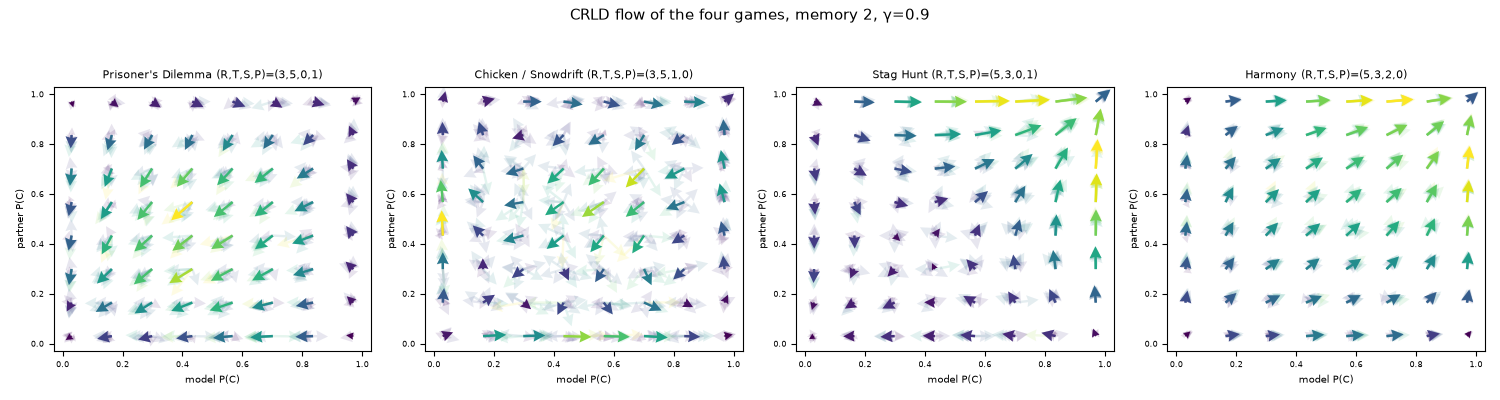

In [5]:
f = 'llm_dynamics/results/flow_grids_qwen8b_base/theory_matrix_m2.png'
if os.path.exists(f): _d(Image(f, width=900))

## 6. How to compare against a trained checkpoint

Serve it with `llm_dynamics/slurm/serve_model.sbatch` (`MODEL_PATH=<merged dir>` or
`LORA=<adapter dir>`), run `TAG=<tag> MODEL=<served name> ENDPOINT_FILE=... sbatch
llm_dynamics/slurm/run_suite_v3.sbatch`, then `TAG=<tag> VERSION=v3 python
llm_dynamics/build_notebook.py --execute` and `reciprocity-figure --probes <base> <trained>`.
